# 🚀 Tutorial FastAPI — Crowd Level Classification

Notebook ini adalah panduan lengkap untuk:
1. Menyiapkan environment
2. Menjalankan server FastAPI
3. Menggunakan semua endpoint
4. Memvisualisasikan hasil prediksi

---
## 📁 Struktur File
```
project/
├── main.py              ← kode FastAPI
├── requirements.txt     ← daftar library
├── client_test.py       ← skrip test otomatis
├── best_model.h5        ← model CNN (hasil training)
└── tutorial_fastapi.ipynb  ← notebook ini
```

> ⚠️ **Pastikan** file `best_model.h5` sudah ada (hasil training dari `cnn_crowd_level.ipynb`)

---
## ⚙️ Step 1 — Install Dependencies

In [ ]:
# Install semua library yang dibutuhkan
#!pip install fastapi uvicorn[standard] python-multipart Pillow requests -q
#print('✅ Instalasi selesai')

---
## 🖥️ Step 2 — Jalankan Server FastAPI

Server harus dijalankan di **terminal terpisah** (bukan di dalam notebook), karena akan berjalan terus-menerus.

### Cara 1 — Terminal biasa
```bash
# Masuk ke folder project
cd path/ke/folder/project

# Jalankan server
uvicorn main:app --reload --host 0.0.0.0 --port 8000
```

### Cara 2 — Dari dalam notebook (background process)
Jalankan cell di bawah ini:

In [15]:
import subprocess, time, requests

# Jalankan server di background
server = subprocess.Popen(
    ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Tunggu server siap
print("⏳ Menunggu server siap...", end="")
for _ in range(15):
    time.sleep(1)
    print(".", end="", flush=True)
    try:
        r = requests.get("http://127.0.0.1:8000/health", timeout=2)
        if r.status_code == 200:
            print("\n✅ Server berhasil berjalan di http://127.0.0.1:8000")
            break
    except:
        pass
else:
    print("\n⚠️  Server belum merespons. Cek apakah main.py ada di direktori yang sama.")

⏳ Menunggu server siap.......
✅ Server berhasil berjalan di http://127.0.0.1:8000


---
## 📋 Step 3 — Buka Dokumentasi Interaktif

Setelah server berjalan, buka browser dan akses:

| URL | Keterangan |
|-----|------------|
| http://127.0.0.1:8000/docs | **Swagger UI** — bisa langsung coba endpoint |
| http://127.0.0.1:8000/redoc | **ReDoc** — dokumentasi yang lebih rapi |
| http://127.0.0.1:8000 | Info API |


In [16]:
# Buka dokumentasi Swagger di browser (opsional)
import webbrowser
webbrowser.open("http://127.0.0.1:8000/docs")
print("🌐 Swagger UI dibuka di browser")

🌐 Swagger UI dibuka di browser


---
## 🔌 Step 4 — Setup Client

In [3]:
import io, json
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

BASE_URL    = "http://127.0.0.1:8000"
CLASS_NAMES = ["Level 0", "Level 1", "Level 2", "Level 3"]
COLORS      = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]

def pprint(response):
    """Pretty print JSON response."""
    print(f"Status : {response.status_code}")
    print(json.dumps(response.json(), indent=2, ensure_ascii=False))

print("✅ Client siap. Base URL:", BASE_URL)

✅ Client siap. Base URL: http://127.0.0.1:8000


---
## 📡 Endpoint 1 — `GET /` Info API

In [4]:
resp = requests.get(f"{BASE_URL}/")
pprint(resp)

Status : 200
{
  "api": "Acne Level Classification API",
  "version": "1.0.0",
  "status": "running",
  "model_ready": true,
  "endpoints": {
    "docs": "/docs",
    "redoc": "/redoc",
    "health": "/health",
    "predict": "/predict",
    "predict_batch": "/predict/batch",
    "model_info": "/model/info"
  }
}


---
## 💚 Endpoint 2 — `GET /health` Health Check

In [5]:
resp = requests.get(f"{BASE_URL}/health")
data = resp.json()
pprint(resp)

# Tampilkan status visual
model_ok = data.get("model_loaded", False)
print(f"\n{'🟢' if model_ok else '🔴'} Model status: {'LOADED' if model_ok else 'NOT LOADED'}")
if not model_ok:
    print("   → Jalankan training di cnn_crowd_level.ipynb dulu")
    print("   → Pastikan best_model.h5 ada di folder yang sama dengan main.py")

Status : 200
{
  "status": "ok",
  "model_loaded": true,
  "tensorflow": "2.15.0"
}

🟢 Model status: LOADED


---
## 🔍 Endpoint 3 — `GET /model/info` Info Model

In [6]:
resp = requests.get(f"{BASE_URL}/model/info")
pprint(resp)

Status : 200
{
  "model_loaded": true,
  "model_path": "best_model.h5",
  "input_shape": "(None, 128, 128, 3)",
  "output_shape": "(None, 4)",
  "num_classes": 4,
  "class_names": [
    "Level 0",
    "Level 1",
    "Level 2",
    "Level 3"
  ]
}


---
## 🖼️ Endpoint 4 — `POST /predict` Prediksi Satu Gambar

### 4a. Menggunakan gambar dari file lokal

In [7]:
# ── Ganti path ini ke gambar Anda ──
IMAGE_PATH = "levle0_1.jpg"   # contoh

import os
if os.path.exists(IMAGE_PATH):
    with open(IMAGE_PATH, "rb") as f:
        resp = requests.post(
            f"{BASE_URL}/predict",
            files={"file": (os.path.basename(IMAGE_PATH), f, "image/jpeg")}
        )
    pprint(resp)
else:
    print(f"⚠️  File '{IMAGE_PATH}' tidak ditemukan.")
    print("   Ganti IMAGE_PATH ke gambar yang ada, atau lanjut ke cell berikutnya (gambar dummy).")

Status : 200
{
  "filename": "levle0_1.jpg",
  "predicted_class": "Level 1",
  "class_index": 1,
  "confidence": 0.8774,
  "confidence_pct": "87.74%",
  "description": "Tingakt Keparahan rendah",
  "probabilities": {
    "Level 0": 0.1121,
    "Level 1": 0.8774,
    "Level 2": 0.0101,
    "Level 3": 0.0004
  },
  "inference_time_ms": 636.27
}


In [8]:
import os
MODEL_PATH   = os.getenv("MODEL_PATH", "../best_model.h5")
print("MODEL_PATH:", MODEL_PATH)
print("File exists:", os.path.exists(MODEL_PATH))

MODEL_PATH: ../best_model.h5
File exists: True


### 4b. Menggunakan gambar dummy (untuk demo tanpa dataset)

In [9]:
def make_dummy_image(label_hint=None):
    """
    Buat gambar dummy 128x128.
    label_hint: 0-3 untuk memberi warna dominan sesuai kelas
    """
    base = [
        [50,  100, 200],   # Level 0 – biru
        [80,  180, 80],    # Level 1 – hijau
        [200, 130, 50],    # Level 2 – oranye
        [180, 50,  80],    # Level 3 – merah
    ]
    color = base[label_hint] if label_hint is not None else [128, 128, 128]
    arr   = np.random.randint(0, 50, (128, 128, 3), dtype=np.uint8)
    arr  += np.array(color, dtype=np.uint8)
    arr   = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


def img_to_bytes(pil_img):
    buf = io.BytesIO()
    pil_img.save(buf, format="JPEG")
    buf.seek(0)
    return buf


# Kirim gambar dummy ke API
dummy_img = make_dummy_image(label_hint=1)   # coba semua 0-3
buf = img_to_bytes(dummy_img)

resp = requests.post(
    f"{BASE_URL}/predict",
    files={"file": ("dummy.jpg", buf, "image/jpeg")}
)
pprint(resp)

Status : 200
{
  "filename": "dummy.jpg",
  "predicted_class": "Level 0",
  "class_index": 0,
  "confidence": 1.0,
  "confidence_pct": "100.00%",
  "description": "Tingkat keparahan Sangat Rendah",
  "probabilities": {
    "Level 0": 1.0,
    "Level 1": 0.0,
    "Level 2": 0.0,
    "Level 3": 0.0
  },
  "inference_time_ms": 134.03
}


### 4c. Visualisasi Hasil Prediksi

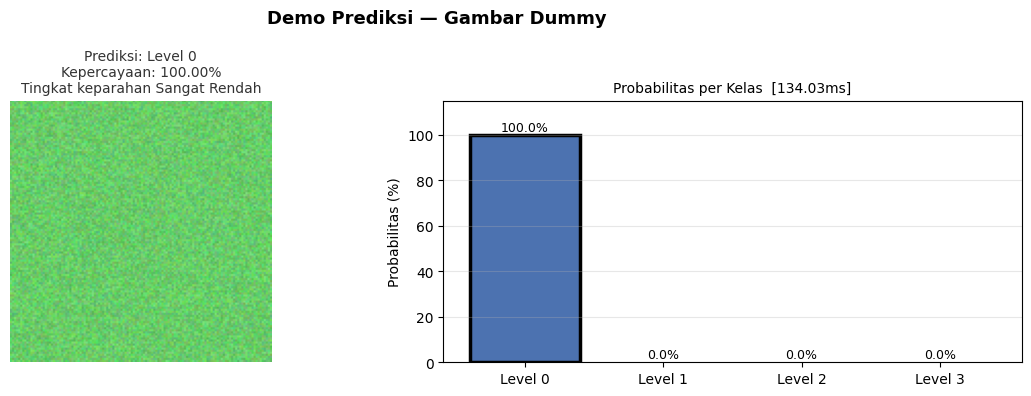

In [10]:
def visualize_prediction(pil_img, api_response, title="Hasil Prediksi"):
    """
    Tampilkan gambar + bar chart probabilitas dari respons API.
    """
    data   = api_response.json()
    probs  = data.get("probabilities", {})
    pred   = data.get("predicted_class", "?")
    conf   = data.get("confidence_pct", "?")
    desc   = data.get("description", "")
    ms     = data.get("inference_time_ms", 0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # Gambar
    axes[0].imshow(pil_img)
    axes[0].axis("off")
    axes[0].set_title(
        f"Prediksi: {pred}\nKepercayaan: {conf}\n{desc}",
        fontsize=10, color="#333"
    )

    # Bar chart probabilitas
    names  = list(probs.keys())
    values = [v * 100 for v in probs.values()]
    bar_colors = [COLORS[CLASS_NAMES.index(n)] if n in CLASS_NAMES else "gray" for n in names]
    # Highlight kelas prediksi
    edge_colors = ["black" if n == pred else "white" for n in names]
    edge_widths = [2.5   if n == pred else 0.5   for n in names]

    bars = axes[1].bar(names, values, color=bar_colors,
                       edgecolor=edge_colors, linewidth=edge_widths)
    for bar, v in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                     f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    axes[1].set_title(f"Probabilitas per Kelas  [{ms}ms]", fontsize=10)
    axes[1].set_ylabel("Probabilitas (%)")
    axes[1].set_ylim([0, 115])
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


# Visualisasikan hasil sebelumnya
visualize_prediction(dummy_img, resp, title="Demo Prediksi — Gambar Dummy")

### 4d. Coba Semua 4 Kelas Sekaligus

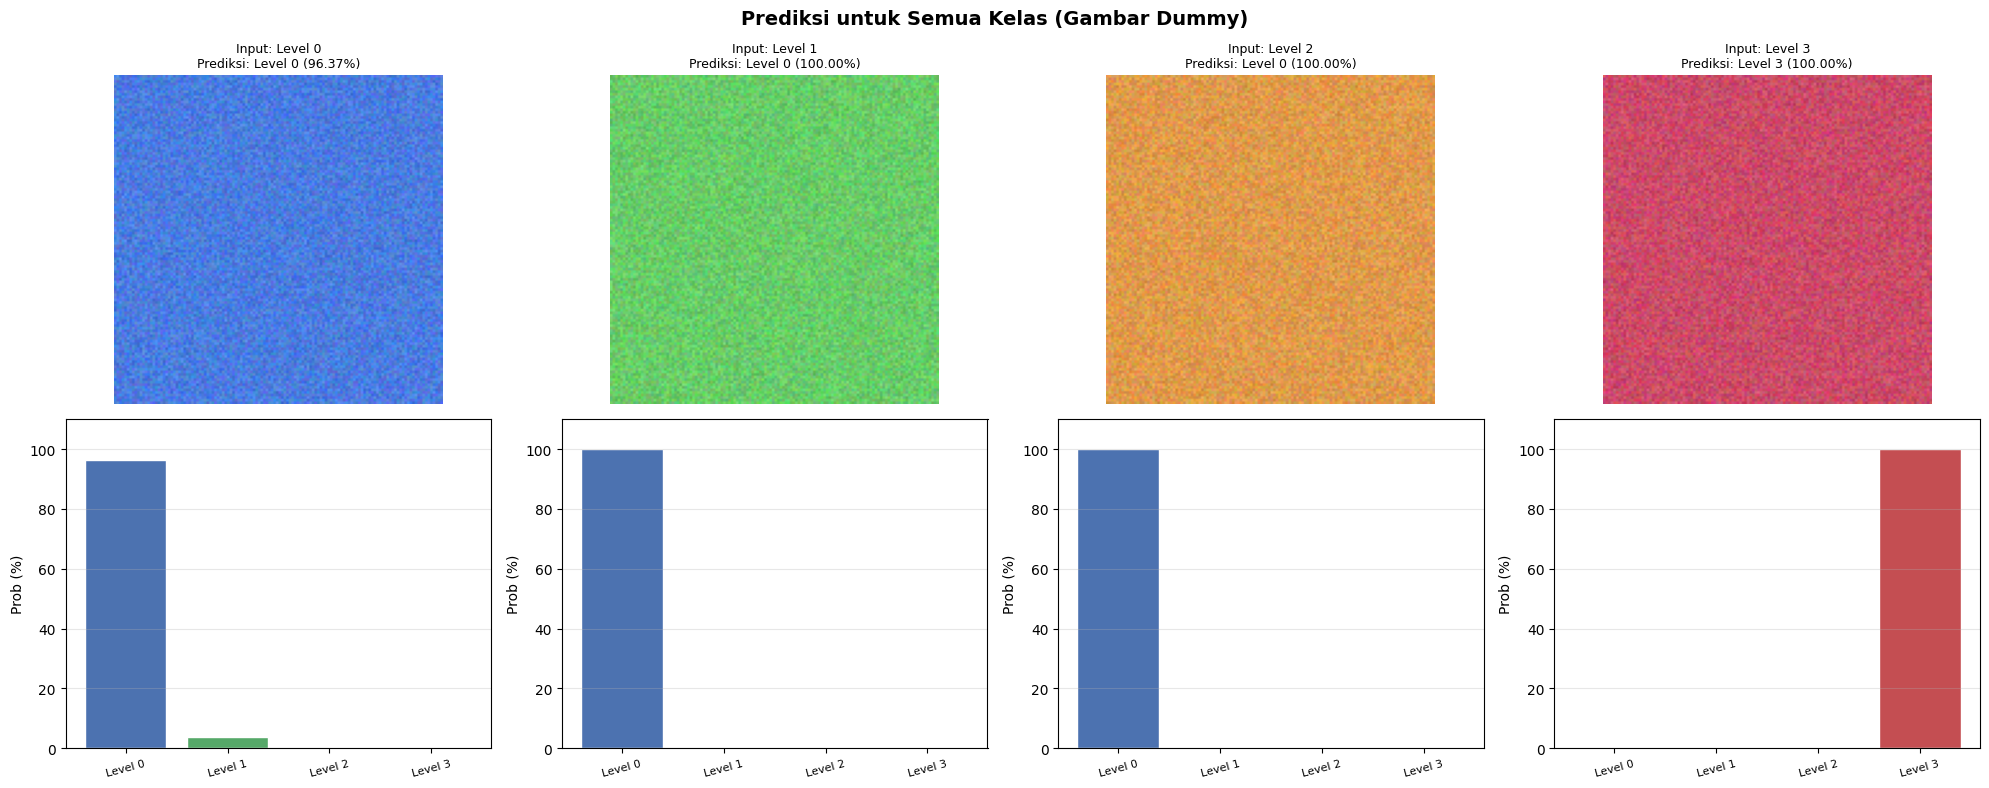

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Prediksi untuk Semua Kelas (Gambar Dummy)", fontsize=14, fontweight="bold")

for col, label_hint in enumerate(range(4)):
    img = make_dummy_image(label_hint=label_hint)
    buf = img_to_bytes(img)

    resp = requests.post(
        f"{BASE_URL}/predict",
        files={"file": (f"class_{label_hint}.jpg", buf, "image/jpeg")}
    )
    data   = resp.json()
    probs  = data.get("probabilities", {})
    pred   = data.get("predicted_class", "?")
    conf   = data.get("confidence_pct", "?")

    # Gambar
    axes[0][col].imshow(img)
    axes[0][col].axis("off")
    axes[0][col].set_title(
        f"Input: {CLASS_NAMES[label_hint]}\nPrediksi: {pred} ({conf})",
        fontsize=9
    )

    # Bar chart
    names  = list(probs.keys())
    values = [v * 100 for v in probs.values()]
    bar_colors = [COLORS[i] for i in range(4)]
    axes[1][col].bar(names, values, color=bar_colors, edgecolor="white")
    axes[1][col].set_ylim([0, 110])
    axes[1][col].set_ylabel("Prob (%)")
    axes[1][col].tick_params(axis='x', rotation=15, labelsize=8)
    axes[1][col].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📦 Endpoint 5 — `POST /predict/batch` Prediksi Banyak Gambar

In [12]:
# Buat 6 gambar dummy untuk batch
N_BATCH = 6
batch_images = []

files = []
for i in range(N_BATCH):
    hint = i % 4
    img  = make_dummy_image(label_hint=hint)
    buf  = img_to_bytes(img)
    batch_images.append(img)
    files.append(("files", (f"batch_{i}_class{hint}.jpg", buf, "image/jpeg")))

resp = requests.post(f"{BASE_URL}/predict/batch", files=files)
data = resp.json()

print(f"Status         : {resp.status_code}")
print(f"Total gambar   : {data['total_images']}")
print(f"Total waktu    : {data['total_time_ms']} ms")
print(f"Rata-rata/gambar: {data['total_time_ms']/data['total_images']:.1f} ms")
print("\nHasil per gambar:")
print("-" * 65)
print(f"{'Filename':<30} {'Prediksi':<12} {'Confidence'}")
print("-" * 65)
for r in data["results"]:
    print(f"{r['filename']:<30} {r['predicted_class']:<12} {r['confidence_pct']}")

Status         : 200
Total gambar   : 6
Total waktu    : 626.7 ms
Rata-rata/gambar: 104.5 ms

Hasil per gambar:
-----------------------------------------------------------------
Filename                       Prediksi     Confidence
-----------------------------------------------------------------
batch_0_class0.jpg             Level 0      96.38%
batch_1_class1.jpg             Level 0      100.00%
batch_2_class2.jpg             Level 0      100.00%
batch_3_class3.jpg             Level 3      99.99%
batch_4_class0.jpg             Level 0      96.16%
batch_5_class1.jpg             Level 0      100.00%


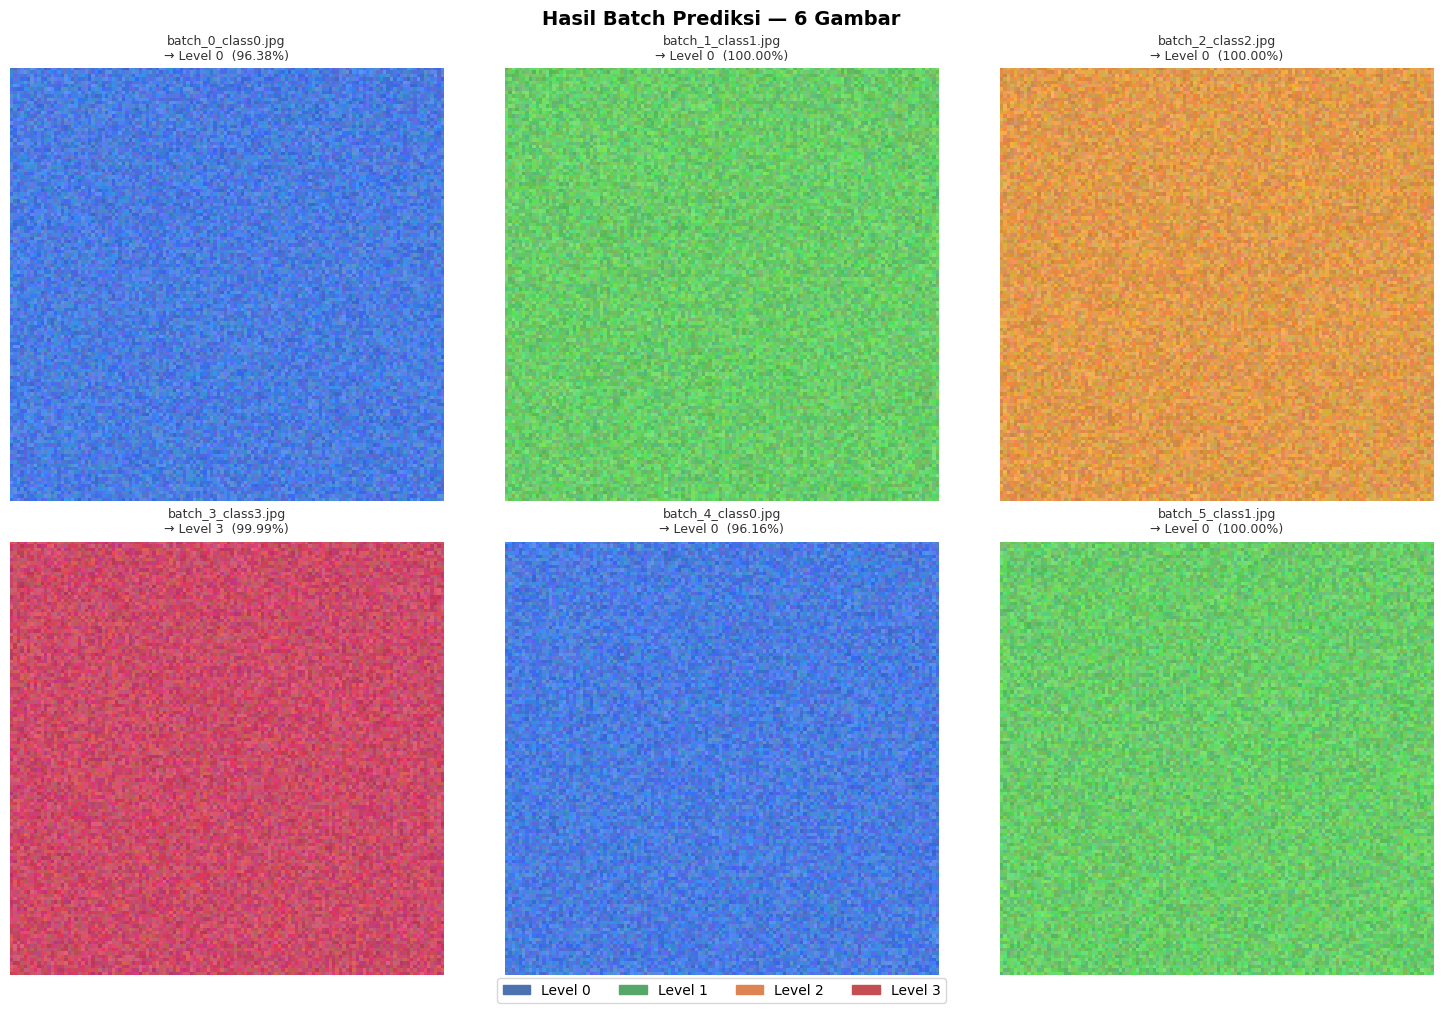

In [13]:
# Visualisasi batch results
results = data["results"]
n_cols  = 3
n_rows  = (len(results) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
fig.suptitle(f"Hasil Batch Prediksi — {len(results)} Gambar", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, (img, res) in enumerate(zip(batch_images, results)):
    pred  = res["predicted_class"]
    conf  = res["confidence_pct"]
    idx   = res["class_index"]
    color = COLORS[idx] if 0 <= idx <= 3 else "gray"

    axes[i].imshow(img)
    axes[i].axis("off")

    # Border warna sesuai prediksi
    for spine in axes[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)
        spine.set_visible(True)

    axes[i].set_title(
        f"{res['filename']}\n→ {pred}  ({conf})",
        fontsize=9, color="#333"
    )

# Sembunyikan cell kosong
for j in range(len(results), len(axes)):
    axes[j].axis("off")

# Legend
patches = [mpatches.Patch(color=c, label=n) for c, n in zip(COLORS, CLASS_NAMES)]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

---
## 🖥️ Cara Pakai via curl (Terminal)

Anda juga bisa memanggil API langsung dari terminal tanpa Python:

```bash
# Health check
curl http://127.0.0.1:8000/health

# Info model
curl http://127.0.0.1:8000/model/info

# Prediksi satu gambar
curl -X POST http://127.0.0.1:8000/predict \
     -F "file=@/path/ke/gambar.jpg"

# Prediksi batch
curl -X POST http://127.0.0.1:8000/predict/batch \
     -F "files=@gambar1.jpg" \
     -F "files=@gambar2.jpg" \
     -F "files=@gambar3.jpg"
```

---
## ⚙️ Konfigurasi Environment Variable

Path model bisa dikonfigurasi tanpa mengubah kode:

```bash
# Linux / Mac
export MODEL_PATH="/path/ke/model/best_model.h5"
uvicorn main:app --reload

# Windows PowerShell
$env:MODEL_PATH = "C:\path\ke\model\best_model.h5"
uvicorn main:app --reload
```

---
## ❌ Error Handling

API mengembalikan kode error standar HTTP:

In [ ]:
# Test: kirim file bukan gambar → harus return 415
resp = requests.post(
    f"{BASE_URL}/predict",
    files={"file": ("test.txt", b"bukan gambar", "text/plain")}
)
print(f"Test file non-gambar → Status: {resp.status_code}")
print(json.dumps(resp.json(), indent=2))

In [26]:
# Tabel kode error
errors = {
    200: ("OK",                          "Prediksi berhasil"),
    400: ("Bad Request",                 "Request tidak valid (misal: tidak ada file)"),
    413: ("Request Entity Too Large",    "File melebihi batas 10 MB"),
    415: ("Unsupported Media Type",      "Format file bukan JPEG/PNG"),
    422: ("Unprocessable Entity",        "Gambar tidak bisa diproses"),
    503: ("Service Unavailable",         "Model belum dimuat"),
}

print(f"{'Code':<6} {'Status':<32} {'Penyebab'}")
print("-" * 75)
for code, (status, desc) in errors.items():
    print(f"{code:<6} {status:<32} {desc}")

Code   Status                           Penyebab
---------------------------------------------------------------------------
200    OK                               Prediksi berhasil
400    Bad Request                      Request tidak valid (misal: tidak ada file)
413    Request Entity Too Large         File melebihi batas 10 MB
415    Unsupported Media Type           Format file bukan JPEG/PNG
422    Unprocessable Entity             Gambar tidak bisa diproses
503    Service Unavailable              Model belum dimuat


---
## 🛑 Hentikan Server

In [17]:
# Hentikan server yang dijalankan dari notebook (Step 2 Cara 2)
try:
    server.terminate()
    print("✅ Server berhasil dihentikan")
except NameError:
    print("Server tidak dijalankan dari notebook ini.")
    print("Hentikan dengan Ctrl+C di terminal yang menjalankan uvicorn.")

✅ Server berhasil dihentikan


---
## 📌 Ringkasan Endpoint

| Method | Endpoint | Fungsi |
|--------|----------|--------|
| `GET` | `/` | Info API |
| `GET` | `/health` | Status server & model |
| `GET` | `/model/info` | Detail model (shape, kelas) |
| `POST` | `/predict` | Prediksi **satu** gambar |
| `POST` | `/predict/batch` | Prediksi **banyak** gambar |

## 🔗 Dokumentasi Interaktif
- **Swagger UI**: http://127.0.0.1:8000/docs
- **ReDoc**: http://127.0.0.1:8000/redoc